In [ ]:
import os
import json
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader

from core.models.MAE import (
    MAEResNet,
    MAEResNetConfig,
    patchify,
    unpatchify
)
from core.datasets.pokemon_dataset import PokemonDataset
from core.image_utils import show_batch_grid

/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DEVICE = "cuda:0"
IMG_SIZE = 128

dataset_path = "./data/CelebA"
dataset_type = "CelebA"

pokemon_dataset = PokemonDataset(root_dir=dataset_path, img_size=IMG_SIZE, dataset_type=dataset_type)

Number of images: 202599


In [3]:
mae_config_path = "./configs/MAE_configs/MAE-128_pixel_img128.json"
with open(mae_config_path, "r") as f:
    config_dict = json.load(f)

mae_config = MAEResNetConfig.from_dict(config_dict)
mae = MAEResNet(mae_config).cuda()

# mae = MAEResNet.from_pretrained(
#     ""
# ).cuda()

opt = torch.optim.AdamW(
    mae.parameters(), 
    lr=2e-4,
    betas=(0.9, 0.95),
    weight_decay=0.02,
)

In [4]:
batch_size = 2048
dataloader = DataLoader(pokemon_dataset, batch_size=batch_size, shuffle=True, num_workers=8)

epoch: 22


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x76f03e34c180>
Traceback (most recent call last):
  File "/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 1618, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
  File "/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/multiprocessing/popen_fork.py", line 41, in wait
    if not wait([self.sentinel], timeout):
  File "/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/multiprocessing/connection.py", line 1148, in wait
    ready = selector.select(timeout)
  File "/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/selectors.py", li

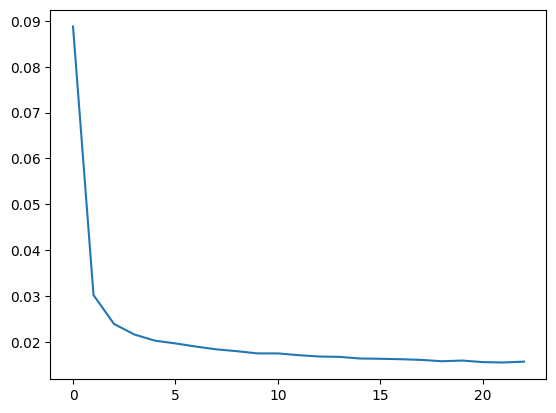

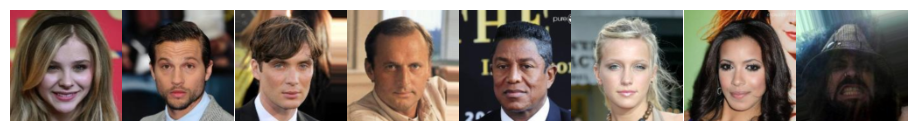

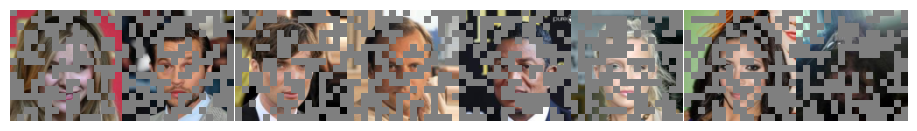

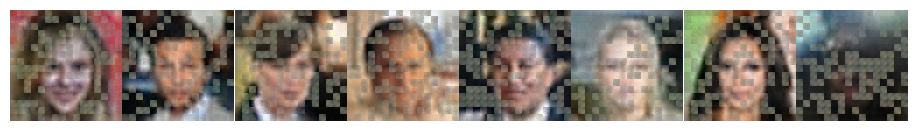

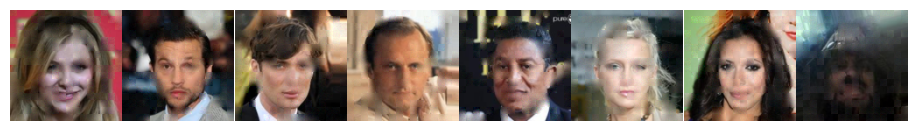

  6%|▌         | 6/99 [00:10<02:21,  1.52s/it]

In [ ]:
n_epochs = 1000
save_step_epochs = 10
plot_step_epochs = 1
save_path = f"./checkpoints/CelebA/pixel-MAE_img{IMG_SIZE}_ch{mae.base_channels}_mask{mae.mask_ratio}_patch{mae.mask_patch_size}"


loss_history = []
plot_loss_acc = []
for e in range(n_epochs):
    for step, batch in enumerate(tqdm(dataloader)):
        batch = batch.to(torch.bfloat16).cuda()
        loss = mae(batch)[0]
        loss.backward()
        opt.step()
        opt.zero_grad()
        plot_loss_acc.append(loss.item())

    if e % save_step_epochs == 0:
        os.makedirs(save_path, exist_ok=True)
        mae.save_pretrained(f"{save_path}/epoch-{e}")

    if e % plot_step_epochs == 0:
        loss_history.append(sum(plot_loss_acc) / len(plot_loss_acc))
        plot_loss_acc = []
        clear_output(wait=True)
        print("epoch:", e)
        plt.plot(loss_history)
        with torch.no_grad():
            test_imgs = next(iter(dataloader))[:8].to(torch.bfloat16).cuda()
            test_imgs_shape = test_imgs.shape
            show_batch_grid(test_imgs, n=8, figsize=(9, 9), denormalize=True)

            test_imgs_patches = patchify(test_imgs, mae.input_patch_size)
            mask = mae.make_patch_mask(test_imgs_patches)
            test_imgs_patches_masked = test_imgs_patches * (1.0 - mask)
            show_batch_grid(
                unpatchify(test_imgs_patches_masked, mae.input_patch_size, 3), 
                n=8, figsize=(9, 9), denormalize=True
            )

            feats = mae.encoder(test_imgs_patches_masked)
            recon = mae.decoder(feats)
            show_batch_grid(
                unpatchify(recon, mae.input_patch_size, 3), 
                n=8, figsize=(9, 9), denormalize=True
            )

            recon = recon * mask + test_imgs_patches_masked
            show_batch_grid(
                unpatchify(recon, mae.input_patch_size, 3), 
                n=8, figsize=(9, 9), denormalize=True
            )
            plt.show()